DATASET LOADED SUCCESSFULLY

FIRST 5 ROWS
                                                Text          One_Hot_Label  \
0  During the period of falling in love, each tim...  [1, 0, 0, 0, 0, 0, 0]   
1         When I was involved in a traffic accident.  [0, 1, 0, 0, 0, 0, 0]   
2  When I was driving home after  several days of...  [0, 0, 1, 0, 0, 0, 0]   
3   When I lost the person who meant the most to me.  [0, 0, 0, 1, 0, 0, 0]   
4  The time I knocked a deer down - the sight of ...  [0, 0, 0, 0, 1, 0, 0]   

  Emotion_Label  Character_Count  Word_Count  
0           joy              111          23  
1          fear               42           8  
2         anger              176          34  
3       sadness               48          11  
4       disgust              217          42  

LAST 5 ROWS
                                                   Text  \
7475  Two years back someone invited me to be the tu...   
7476  I had taken the responsibility to do something...   
7477  I was

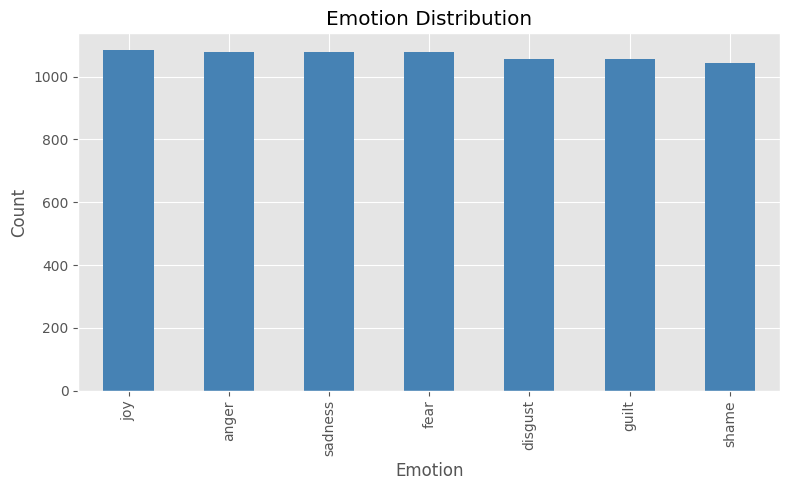


CHARACTER LENGTH STATISTICS
count    7480.000000
mean      114.433824
std        74.709939
min         8.000000
25%        60.000000
50%        98.000000
75%       152.000000
max       863.000000
Name: Character_Count, dtype: float64


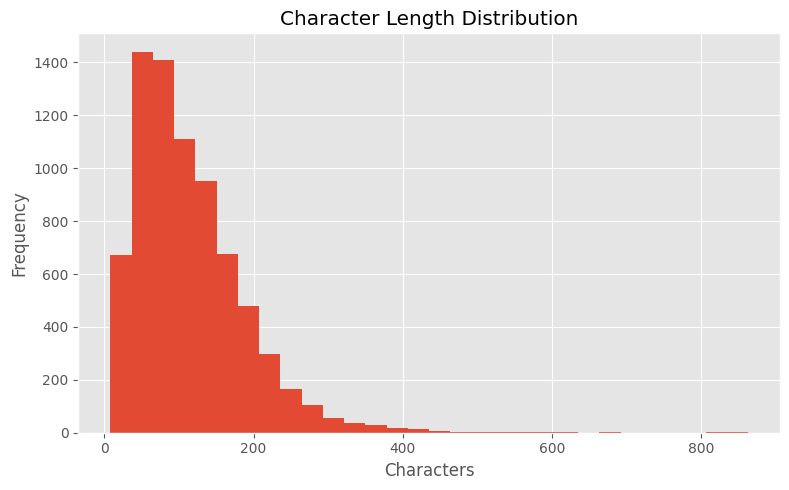


WORD COUNT STATISTICS
count    7480.000000
mean       22.226604
std        14.712428
min         1.000000
25%        12.000000
50%        19.000000
75%        30.000000
max       178.000000
Name: Word_Count, dtype: float64


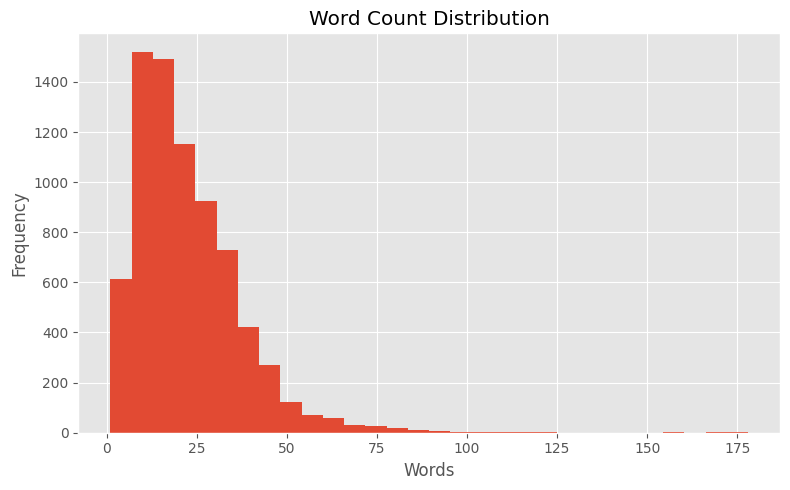


VOCABULARY SIZE : 13692

TOP 20 MOST FREQUENT WORDS
i               10703
the             6083
a               6037
to              4724
my              4710
and             4606
was             4536
when            3656
of              3005
in              2755
had             2584
that            2116
me              1643
for             1595
not             1564
with            1537
at              1445
it              1184
on              1022
very            977


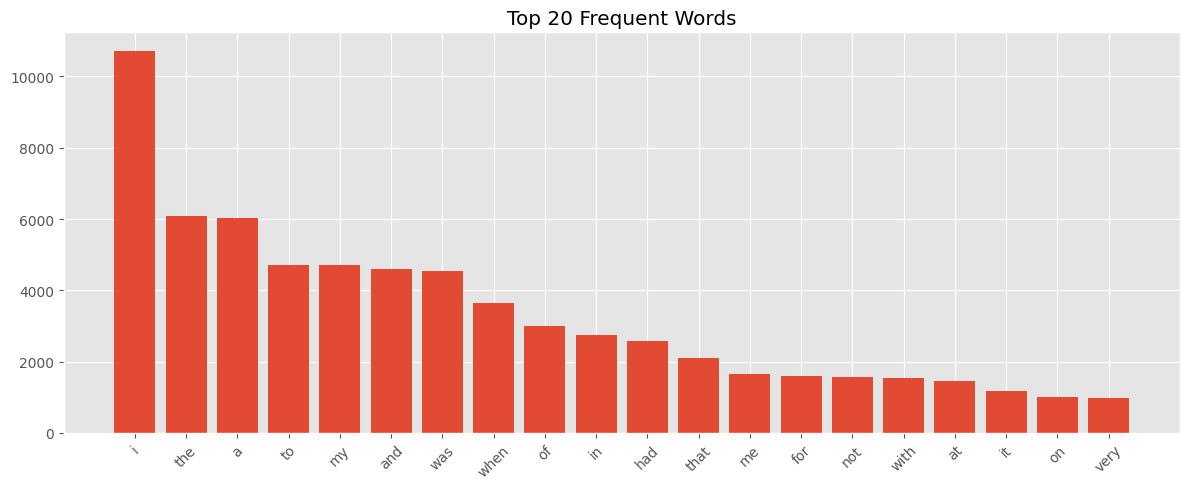


ROWS CONTAINING SPECIAL CHARACTERS : 7474
ROWS CONTAINING NUMBERS : 522
ROWS CONTAINING URLs : 0
ROWS CONTAINING EMAILS : 0
ROWS CONTAINING HTML TAGS : 0


DATASET SUMMARY
Total Samples          : 7480
Total Features         : 5
Missing Values         : 0
Duplicate Samples      : 57
Duplicate Rows         : 93
Conflicting Texts      : 8
Vocabulary Size        : 13692
Special Characters     : 7474
Numbers                : 522
URLs                   : 0
Emails                 : 0
HTML Tags              : 0

Removing conflicting texts...
Conflicting Texts Found : 8

Removing exact duplicate rows...
Rows Before : 7461
Rows After  : 7407
Rows Removed: 54

FINAL DATASET SHAPE : (7407, 5)

Remaining Duplicate Rows : 0
Remaining Conflicting Texts : 0

Cleaned dataset saved successfully.
File Name : emotion_dataset_cleaned.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use("ggplot")

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/raw/emotion_dataset.csv")

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

# ==========================================================
# Inspect Dataset
# ==========================================================

print("\nFIRST 5 ROWS")
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATASET INFORMATION")
df.info()

# ==========================================================
# Missing Values
# ==========================================================

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nMISSING VALUE PERCENTAGE")
print((df.isnull().sum() / len(df)) * 100)

# ==========================================================
# Duplicate Analysis
# ==========================================================

duplicates = df.duplicated().sum()

print("\nDUPLICATE ROWS :", duplicates)

if duplicates > 0:
    print("\nRepeated Duplicate Rows")
    print(df[df.duplicated()])

# Display all duplicate rows (including first occurrence)

duplicate_rows = df[df.duplicated(keep=False)]

print("\nTOTAL DUPLICATE ROWS :", len(duplicate_rows))

if len(duplicate_rows) > 0:
    print(duplicate_rows.sort_values(by="Text").head(20))

# ==========================================================
# Conflicting Labels
# ==========================================================

conflicting = (
    df.groupby("Text")["Emotion_Label"]
      .nunique()
)

conflicting = conflicting[conflicting > 1]

print("\nTEXTS WITH CONFLICTING LABELS :", len(conflicting))

conflicting_texts = conflicting.index

conflicting_rows = (
    df[df["Text"].isin(conflicting_texts)]
      .sort_values("Text")
)

if len(conflicting_rows) > 0:
    print("\nCONFLICTING ROWS")
    print(conflicting_rows)

# ==========================================================
# Class Distribution
# ==========================================================

print("\nCLASS DISTRIBUTION")
print(df["Emotion_Label"].value_counts())

plt.figure(figsize=(8, 5))

df["Emotion_Label"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# ==========================================================
# Character Length Analysis
# ==========================================================

df["Character_Count"] = df["Text"].apply(len)

print("\nCHARACTER LENGTH STATISTICS")
print(df["Character_Count"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    df["Character_Count"],
    bins=30
)

plt.title("Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ==========================================================
# Word Count Analysis
# ==========================================================

df["Word_Count"] = df["Text"].apply(
    lambda x: len(str(x).split())
)

print("\nWORD COUNT STATISTICS")
print(df["Word_Count"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    df["Word_Count"],
    bins=30
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ==========================================================
# Vocabulary Analysis
# ==========================================================

all_words = []

for text in df["Text"]:
    all_words.extend(
        str(text).lower().split()
    )

vocabulary = set(all_words)

print("\nVOCABULARY SIZE :", len(vocabulary))

word_frequency = Counter(all_words)

print("\nTOP 20 MOST FREQUENT WORDS")

for word, freq in word_frequency.most_common(20):
    print(f"{word:15} {freq}")

top_words = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 5))

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.tight_layout()
plt.show()

# ==========================================================
# Text Pattern Analysis
# ==========================================================

# Special Characters

special_pattern = r"[^A-Za-z0-9\s]"

special_rows = df["Text"].str.contains(
    special_pattern,
    regex=True
).sum()

print("\nROWS CONTAINING SPECIAL CHARACTERS :", special_rows)

# Numbers

number_pattern = r"\d"

number_rows = df["Text"].str.contains(
    number_pattern,
    regex=True
).sum()

print("ROWS CONTAINING NUMBERS :", number_rows)

# URLs

url_pattern = r"https?://\S+|www\.\S+"

url_rows = df["Text"].str.contains(
    url_pattern,
    regex=True
).sum()

print("ROWS CONTAINING URLs :", url_rows)

# Email Addresses

email_pattern = r"\S+@\S+"

email_rows = df["Text"].str.contains(
    email_pattern,
    regex=True
).sum()

print("ROWS CONTAINING EMAILS :", email_rows)

# HTML Tags

html_pattern = r"<.*?>"

html_rows = df["Text"].str.contains(
    html_pattern,
    regex=True
).sum()

print("ROWS CONTAINING HTML TAGS :", html_rows)

# ==========================================================
# Dataset Summary
# ==========================================================

print("\n")
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Total Samples          : {len(df)}")
print(f"Total Features         : {len(df.columns)}")
print(f"Missing Values         : {df.isnull().sum().sum()}")
print(f"Duplicate Samples      : {duplicates}")
print(f"Duplicate Rows         : {len(duplicate_rows)}")
print(f"Conflicting Texts      : {len(conflicting)}")
print(f"Vocabulary Size        : {len(vocabulary)}")
print(f"Special Characters     : {special_rows}")
print(f"Numbers                : {number_rows}")
print(f"URLs                   : {url_rows}")
print(f"Emails                 : {email_rows}")
print(f"HTML Tags              : {html_rows}")

print("=" * 70)

# ==========================================================
# Remove Conflicting Labels
# ==========================================================

print("\nRemoving conflicting texts...")

conflicting_texts = (
    df.groupby("Text")["Emotion_Label"]
      .nunique()
)

conflicting_texts = conflicting_texts[
    conflicting_texts > 1
].index

print("Conflicting Texts Found :", len(conflicting_texts))

df = df[
    ~df["Text"].isin(conflicting_texts)
]

# ==========================================================
# Remove Exact Duplicates
# ==========================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nRemoving exact duplicate rows...")

print(f"Rows Before : {before}")
print(f"Rows After  : {after}")
print(f"Rows Removed: {before - after}")

# ==========================================================
# Final Dataset Information
# ==========================================================

print("\nFINAL DATASET SHAPE :", df.shape)

print("\nRemaining Duplicate Rows :", df.duplicated().sum())

remaining_conflicts = (
    df.groupby("Text")["Emotion_Label"]
      .nunique()
)

remaining_conflicts = remaining_conflicts[
    remaining_conflicts > 1
]

print("Remaining Conflicting Texts :", len(remaining_conflicts))

# ==========================================================
# Save Clean Dataset
# ==========================================================

df.to_csv(
    "emotion_dataset_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")
print("File Name : emotion_dataset_cleaned.csv")